### Imports

In [1]:
%run ../CNN_LSTM/CNN_LSTM.ipynb

2025-07-29 08:44:21.878095: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 08:44:26.633344: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-29 08:44:26.646808: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-29 08:44:36.926507: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import seaborn as sns
from tensorflow.keras.models import clone_model

In [18]:
janela_tempo = 12
SEED = 2020
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Categorização Geral (por tipo de tarefa e domínio)

| Tipo de Transfer Learning          | Tarefa Origem vs Alvo | Domínio Origem vs Alvo | Rótulos no Domínio Alvo | Exemplo típico                                          |
| ---------------------------------- | --------------------- | ---------------------- | ----------------------- | ------------------------------------------------------- |
| **Inductive Transfer Learning**    | ✅ Diferente           | ✅ Mesmo ou diferente   | ✅ Sim (supervisionado)  | Fine-tuning para nova tarefa                            |
| **Transductive Transfer Learning** | ❌ Mesma tarefa        | ✅ Diferente            | ❌ Não (não rotulado)    | Domain Adaptation                                       |
| **Unsupervised Transfer Learning** | ✅ Diferente           | ✅ Mesmo ou diferente   | ❌ Não (sem rótulos)     | Pré-treinar em dados grandes e transferir p/ clustering |


### Categorização por Mecanismo de Transferência

| Tipo técnico de TL   | O que transfere?                   | Exemplos                         |
| -------------------- | ---------------------------------- | -------------------------------- |
| **Parameter-based**  | Pesos e arquiteturas do modelo     | Fine-tuning, multitask           |
| **Instance-based**   | Dados reponderados ou selecionados | TrAdaBoost, importance weighting |
| **Feature-based**    | Representações (features latentes) | MMD, CORAL, Adversarial TL       |
| **Relational-based** | Estrutura relacional (grafos etc.) | GNNs, Knowledge Transfer in NLP  |


| Método/Categoria         | Tipo de Conhecimento Transferido        | Relacionado a                     | Exemplos / Técnicas Comuns                                      | Categoria Clássica   |
| ------------------------ | --------------------------------------- | --------------------------------- | --------------------------------------------------------------- | -------------------- |
| **Fine-tuning**          | Pesos (parâmetros da rede)              | Parameter-based, Network-based    | Descongelar camadas e ajustar pesos com learning rate menor     | **Parameter-based**  |
| **Feature extraction**   | Representações (features latentes)      | Feature-based, Mapping-based      | Usar camadas congeladas para extrair embeddings                 | **Feature-based**    |
| **Instance-based TL**    | Dados da tarefa origem (instâncias)     | Domain adaptation                 | Reponderação, seleção inteligente de amostras, TrAdaBoost       | **Instance-based**   |
| **Parameter-based TL**   | Parâmetros do modelo (pesos)            | Fine-tuning, Network-based        | Inicializar modelo alvo com pesos da tarefa origem              | **Parameter-based**  |
| **Feature-based TL**     | Espaços de representação                | Feature extraction, Mapping-based | Mapeamento via MMD, autoencoders, adversarial domain adaptation | **Feature-based**    |
| **Network-based TL**     | Arquitetura e pesos da rede             | Fine-tuning, Parameter-based      | Compartilhamento parcial de arquitetura, multitask learning     | **Parameter-based**  |
| **Mapping-based TL**     | Representações e domínios               | Feature-based                     | TCA, MMD, CORAL, Subspace Alignment                             | **Feature-based**    |
| **Adversarial-based TL** | Representações (invariância de domínio) | Feature-based                     | DANN (Domain-Adversarial NN), GANs para adaptação de domínio    | **Feature-based**    |
| **Relational-based TL**  | Relações entre entidades                | Knowledge graph, NLP              | Transferência em grafos ou modelos relacionais (ex: GNNs)       | **Relational-based** |


### Como tudo se conecta?

| Nível        | Categoria        | Exemplos ou Subtipos            |
| ------------ | ---------------- | ------------------------------- |
| **Geral**    | Inductive TL     | Fine-tuning, multitask learning |
|              | Transductive TL  | Domain adaptation, adversarial  |
|              | Unsupervised TL  | Feature extraction sem rótulos  |
| **Mecânico** | Parameter-based  | Fine-tuning                     |
|              | Instance-based   | TrAdaBoost, Reweighting         |
|              | Feature-based    | MMD, DANN, PCA, CORAL           |
|              | Relational-based | GNNs, NLP knowledge graphs      |


### Functions

In [19]:
def prepare_data(estacao):
    anual_df = load_and_filter(estacao, 7, 18, False).set_index("data_hora")

    list_cols = ["pto_orvalho_min_c", "umi_min_perc", "pressao_min_hpa", "radiacao"]
    df_norm = select_and_normalize_divided(anual_df, list_cols)
    
    df_inupt = df_norm
    df_target = df_norm[["radiacao"]]
    
    X_clima, X_rad, y = data_to_input_and_output_cnn_lstm(df_inupt, df_target, janela=janela_tempo, horizonte=1)
    Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val = train_test_split(X_clima, X_rad, y, test_size=0.3, random_state=42, shuffle=False)


    return Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val, df_inupt, anual_df

def process_base_model(estacao):

    Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val, df_inupt, anual_df = prepare_data(estacao)

    model = create_cnn_lstm_model(janela_tempo, df_inupt.shape[1], False, False)
    training_model(model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

    results = get_results(model, Xc_train, Xr_train, Xc_val, Xr_val, y_val, anual_df, True)

    return model, results

def process_tl_approachs(base_model, estacao, with_fine_tuning):

    Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val, df_inupt, anual_df = prepare_data(estacao)
    local_model = clone_model(base_model)
    local_model.trainable = False

    for layer in local_model.layers:
        layer.trainable = False

    # CNN
    cnn_layer_1 = local_model.get_layer("cnn_layer_1")
    batch_norm_layer_1 = local_model.get_layer("batch_norm_layer_1")
    cnn_layer_2 = local_model.get_layer("cnn_layer_2")
    max_pool_layer_1 = local_model.get_layer("max_pool_layer_1")

    n_features = df_inupt.shape[1]
    
    input_clima = Input(shape=(janela_tempo, n_features), name="input_clima")

    x_cnn = cnn_layer_1(input_clima)
    x_cnn = batch_norm_layer_1(x_cnn)
    x_cnn = cnn_layer_2(x_cnn)
    x_cnn = max_pool_layer_1(x_cnn)
    x_cnn = Flatten()(x_cnn)
    x_cnn = Dense(32, activation='relu')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)

    # LSTM
    input_rad = Input(shape=(janela_tempo, 1), name="input_radiacao")

    lstm_layer_1 = local_model.get_layer("bidirectional_12")
    lstm_layer_2 = local_model.get_layer("bidirectional_13")

    if with_fine_tuning:
        lstm_layer_1.trainable = True
        lstm_layer_2.trainable = True

        _optimizer = Adam(1e-5)
        
    else:
        _optimizer = "adam"

    x_lstm = lstm_layer_1(input_rad)
    x_lstm = lstm_layer_2(x_lstm)

    # Criando novo modelo com a CNN LSTM congelada + nova saída
    x = Concatenate()([x_cnn, x_lstm])
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, name="saida", activation='linear')(x)
    
    transfer_model = Model(inputs=[input_clima, input_rad], outputs=output)
    transfer_model.compile(optimizer=_optimizer, loss='mse')

    training_model(transfer_model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

    return get_results(transfer_model, Xc_train, Xr_train, Xc_val, Xr_val, y_val, anual_df)

def process_raw_compare(model, estacao):
    Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val, df_inupt, anual_df = prepare_data(estacao)
    return model, get_results(model, Xc_train, Xr_train, Xc_val, Xr_val, y_val, anual_df)

def process_tl_approach_1(base_model, estacao):
    return process_tl_approachs(base_model, estacao, False)

def process_tl_approach_2(base_model, estacao):
    return process_tl_approachs(base_model, estacao, True)

def get_results(model, Xc_train, Xr_train, Xc_val, Xr_val, y_val, anual_df, show_results=False):
    train_pred = model.predict(x={"input_clima": Xc_train, "input_radiacao": Xr_train}, verbose=0)
    test_pred = model.predict(x={"input_clima": Xc_val, "input_radiacao": Xr_val}, verbose=0)

    if show_results:
        period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
        plot_results_2(test_pred.reshape(test_pred.shape[0]), y_val, period)

    return get_metrics(test_pred, y_val)

def create_table_results_2(station, results, run):
    lr = [run]
    ls = [station]
    
    r = list(results.values())
    lr.extend(ls)
    lr.extend(r)
    
    
    df = pd.DataFrame(
        [lr],
        columns=["run", "station", "mse", "rmse", "mae", "r2"]
    )

    return df
        

# Base model

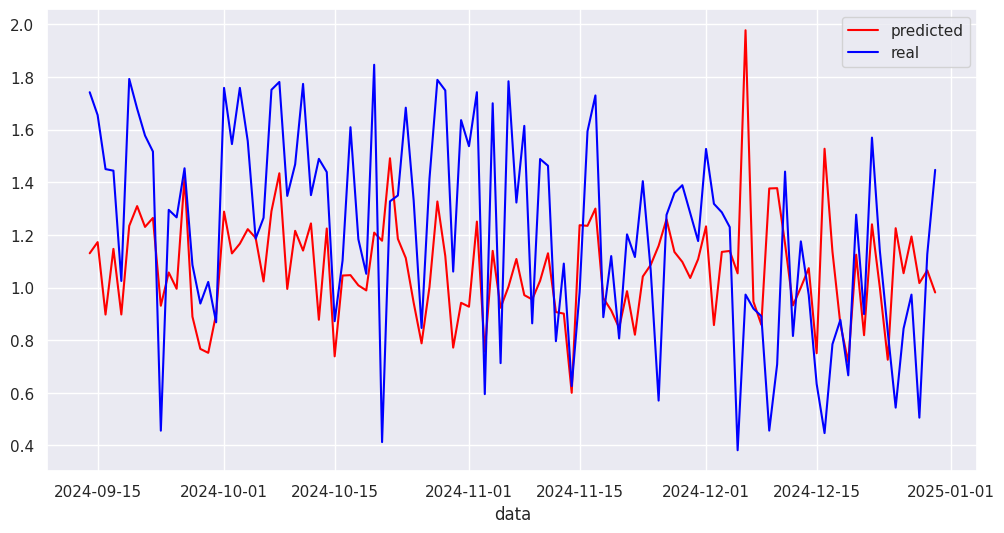

In [20]:
base_model, results = process_base_model("manaus")

In [21]:
print(results)

{'mse': 0.5894472397512242, 'rmse': 0.7677546741969234, 'mae': 0.5596357367209408, 'r2': 0.11232851992953397}


# Transfer Learning
- 1 - manaus
- 2 - itacoatiara
- 3 - apui
- 4 - cuiaba
- 5 - brasilia
- 6 - belo horizonte
- 7 - curitiba
- 8 - pelotas

In [ ]:
l_stations = ["itacoatiara", "apui", "cuiaba", "brasilia", "minas_gerais_bh", "curitiba", "pelotas"]

### Raw compare

,run,station,mse,rmse,mae,r2
0,0,itacoatiara,0.251777,0.501774,0.363943,0.627781
0,0,apui,0.347963,0.589883,0.438639,0.612884
0,0,cuiaba,0.437291,0.661280,0.492592,0.524723
0,0,brasilia,0.355649,0.596363,0.435226,0.638525
0,0,minas_gerais_bh,0.289864,0.538391,0.398795,0.671714
0,0,curitiba,0.338444,0.581759,0.420335,0.577063
0,0,pelotas,0.558620,0.747409,0.570336,0.331268


<Axes: xlabel='station', ylabel='r2'>

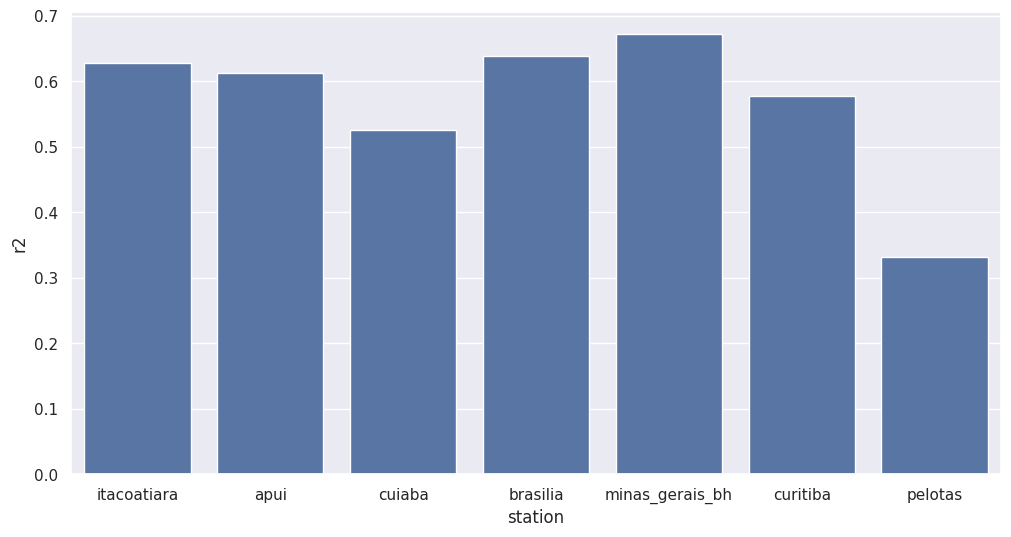

In [120]:
l_df = []
for station in l_stations:
    _, results = process_raw_compare(base_model, station)
    l_df.append(create_table_results_2(station, results, 0))

df_final = pd.concat(l_df)

display(df_final)
sns.barplot(df_final, x = "station", y = "r2")

### Approach 1: Feature Extraction
Freezing LSTM layers and trainig only new Dense

,run,station,mse,rmse,mae,r2
0,0,itacoatiara,0.140462,0.374782,0.261542,0.826961
0,1,itacoatiara,0.169864,0.412145,0.308028,0.773971
0,0,apui,0.359434,0.599528,0.477258,0.460252
0,1,apui,0.361923,0.601600,0.471858,0.529140
0,0,cuiaba,0.404847,0.636276,0.475274,0.539496
0,1,cuiaba,0.358782,0.598984,0.430967,0.693191
0,0,brasilia,0.405218,0.636567,0.461308,0.571543
0,1,brasilia,0.405025,0.636416,0.460476,0.544578
0,0,minas_gerais_bh,0.310570,0.557288,0.412097,0.652457
0,1,minas_gerais_bh,0.313432,0.559850,0.411246,0.666044


<Axes: xlabel='station', ylabel='r2'>

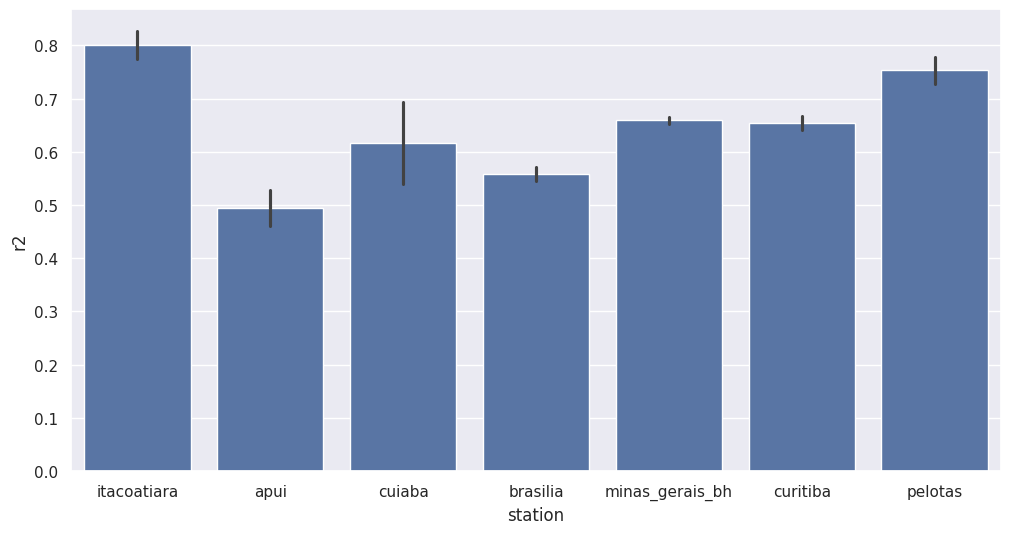

In [123]:
l_df = []

for station in l_stations:
    for i in range(2):
        results = process_tl_approach_1(base_model, station)
        l_df.append(create_table_results_2(station, results, i))

df_final = pd.concat(l_df)

display(df_final)
sns.barplot(df_final, x = "station", y = "r2")

### Approach 2: Fine Tuning
Freezing LSTM layers and trainig only new Dense, and then unfreeze LSTM layers and training in a sall learninig rate.

,run,station,mse,rmse,mae,r2
0,0,itacoatiara,0.189942,0.435823,0.318270,0.758552
0,1,itacoatiara,0.185068,0.430195,0.311620,0.752051
0,0,apui,0.572824,0.756851,0.599589,0.433060
0,1,apui,0.617035,0.785516,0.638797,0.183051
0,0,cuiaba,0.343825,0.586366,0.441710,0.635385
0,1,cuiaba,0.377631,0.614517,0.465774,0.615173
0,0,brasilia,0.422272,0.649825,0.482676,0.579806
0,1,brasilia,0.413191,0.642800,0.485429,0.540253
0,0,minas_gerais_bh,0.328334,0.573005,0.438229,0.614194
0,1,minas_gerais_bh,0.321063,0.566625,0.429505,0.656732


<Axes: xlabel='station', ylabel='r2'>

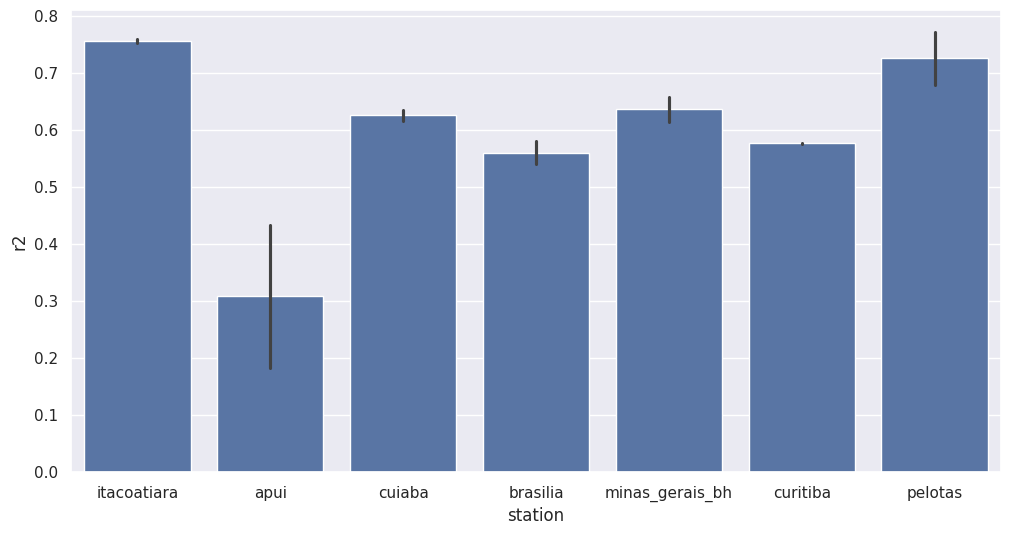

In [124]:
l_df = []
for station in l_stations:
    for i in range(2):
        results = process_tl_approach_2(base_model, station)
        l_df.append(create_table_results_2(station, results, i))

df_final = pd.concat(l_df)

display(df_final)
sns.barplot(df_final, x = "station", y = "r2")

In [11]:
# Feature Extraction (extração de características)
# → Congelar as camadas do modelo base e treinar apenas a nova "cabeça" (camadas finais).
# → Não há ajuste nos pesos pré-treinados.
# → Rápido e seguro, evita overfitting.
# Evidencias na literatura: 1

# Fine-tuning (ajuste fino) (incialização de pesos)
# → Primeiro congela a base, treina a cabeça (como acima).
# → Depois, descongela uma ou mais camadas do modelo base e treina com uma taxa de aprendizado menor.
# → Permite o modelo se adaptar melhor à nova tarefa.
# Evidencias na literatura: 3

# Proximos passos
- Comparar resultados do modelo treinado desde o incio em uma estação e o resutlado da mesma estação rodando raw.
- Demostrar que peguei os daos com mais diponibilidade de GHI (radiacao)
- Testar o modelo base/TL nas estações proximas e nas distantes
- Testar o TL com estações mais perto e mais distantes, para ver se existe relação
- Testar o TL com menos dados, mais dados, ao treinar em outros dominios
- Pegar outra estação do sarima no lugar de mossoro
- Pegar um modelo treinado em uma estação e, sem o TL, prever. Depois comparar com o TL
- Testar uma terceira abordagem
- Usar estacoes "distantes" para comparar
- Procurar na literatura sobre os pontos chaves e trazer os papers para as referências.